In [4]:
import numpy as np
from sklearn.datasets import fetch_openml

mnist = fetch_openml('mnist_784', version=1, as_frame=False)

X = mnist.data      # images
y = mnist.target    # labels
print(X.min(), X.max())

0 255


In [5]:
X.shape

(70000, 784)

In [6]:
y.shape

(70000,)

Label: 5
(28, 28)


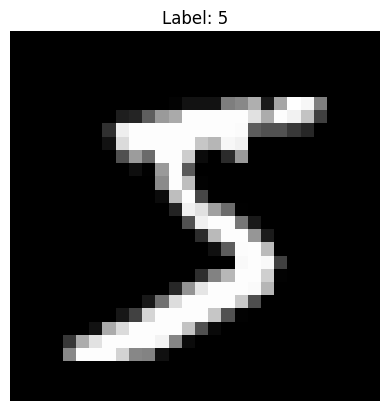

In [7]:
# visually seeing the images

import matplotlib.pyplot as plt

image = X[0].reshape(28, 28)
label = y[0]

print("Label:", label)
print(image.shape)

plt.imshow(image, cmap='gray')
plt.title(f"Label: {label}")
plt.axis('off')
plt.show()

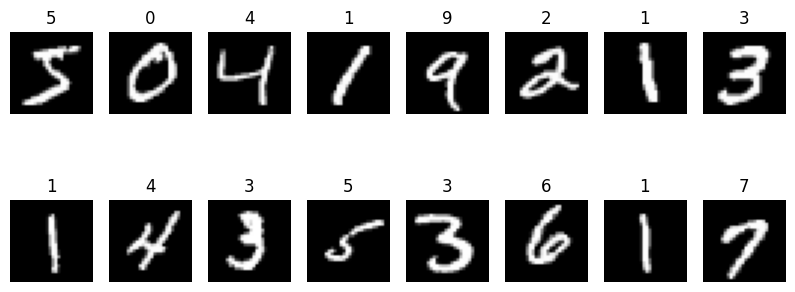

In [8]:
fig, axes = plt.subplots(2, 8, figsize=(10, 4))

for i, ax in enumerate(axes.flat):
  # same logic as visualising each number
  ax.imshow(X[i].reshape(28, 28), cmap='gray')
  ax.set_title(y[i])
  ax.axis('off')

plt.show()

In [9]:
# scaling the number to fit on a scale of 0-1 instead of 0-255, big numbers are bad for NN
# X = mnist.data # rerunning this cell would cause problems as value of X is reassigned, don't rerun without uncommenting this line!
X = X / 255.0
print(X.min(), X.max())

0.0 1.0


In [10]:
def neuron(x, w, b):
    z = np.dot(x, w) + b # z = W.x + b
    return z

In [11]:
np.random.seed(42)

input_size = 784
hidden_size = 64

W1 = np.random.randn(input_size, hidden_size) * 0.01  # from 784 input nodes to 64 nodes in the hidden layer
b1 = np.zeros(hidden_size)

In [12]:
# forward pass
def dense_forward(x, W, b):
    return x @ W + b

# activation function 1
def relu(z):
    return np.maximum(0, z)

x = X[0]   # one image (784,)
z1 = dense_forward(x, W1, b1)

In [13]:
a1 = relu(z1)


In [14]:
output_size = 10

W2 = np.random.randn(hidden_size, output_size) * 0.01 # from 64 nodes in the hidden layer to 10 nodes in the output layer
b2 = np.zeros(output_size)

z2 = a1 @ W2 + b2
print(z2.shape)
z2

(10,)


array([-0.00623388,  0.01002674, -0.00560899, -0.00105169, -0.00683621,
       -0.00116671,  0.00115572,  0.00118079, -0.00495358,  0.00724558])

In [15]:
 # final code starts here - up above was tutorial of implementing one neuron, activation function and such - not the final version

In [16]:
# activation functions
def relu(z):
    return np.maximum(0, z)

def relu_grad(z):
    return (z > 0).astype(float)

def softmax(z):
    z = z - np.max(z)
    exp_z = np.exp(z)
    return exp_z / np.sum(exp_z)

In [17]:
# forward pass
def forward(x):
    z1 = x @ W1 + b1
    a1 = relu(z1)
    z2 = a1 @ W2 + b2
    return z1, a1, z2

In [18]:
# loss function - tells us how wrong the network is
def cross_entropy_loss(probs, y_true):
    return -np.log(probs[y_true] + 1e-9)

In [19]:
# backpropagation
def backward(x, y_true, z1, a1, logits):
    probs = softmax(logits)

    # Gradient of loss w.r.t logits
    dL_dz2 = probs
    dL_dz2[y_true] -= 1

    # Gradients for second layer
    dW2 = np.outer(a1, dL_dz2)
    db2 = dL_dz2

    # Backprop into hidden layer
    da1 = W2 @ dL_dz2
    dz1 = da1 * relu_grad(z1)

    # Gradients for first layer
    dW1 = np.outer(x, dz1)
    db1 = dz1

    return dW1, db1, dW2, db2


In [20]:
# training loop
learning_rate = 0.1
epochs = 5

for epoch in range(epochs):
    for i in range(len(X)):
        x = X[i]
        y_true = int(y[i])

        z1, a1, logits = forward(x)
        probs = softmax(logits)
        loss = cross_entropy_loss(probs, y_true)

        dW1, db1, dW2, db2 = backward(x, y_true, z1, a1, logits)

        W1 -= learning_rate * dW1
        b1 -= learning_rate * db1
        W2 -= learning_rate * dW2
        b2 -= learning_rate * db2


In [23]:
# tracking loss and accuracy
def predict(x):
    _, _, logits = forward(x)
    probs = softmax(logits)
    return np.argmax(probs) # argmax gives the digit with the highest probability - this is our prediction

def compute_accuracy(X, y):
    correct = 0
    for i in range(len(X)):
        if predict(X[i]) == int(y[i]):
            correct += 1
    print(f'Accuracy: {correct / len(X)}')
    return correct / len(X)


def compute_loss(X, y):
    total_loss = 0.0
    for i in range(len(X)):
        _, _, logits = forward(X[i])
        probs = softmax(logits)
        total_loss += cross_entropy_loss(probs, int(y[i]))
    return total_loss / len(X)


In [24]:
learning_rate = 0.1
epochs = 5

loss_history = []
accuracy_history = []

for epoch in range(epochs):
    for i in range(len(X)):
        x = X[i]
        y_true = int(y[i])

        z1, a1, logits = forward(x)
        dW1, db1, dW2, db2 = backward(x, int(y_true), z1, a1, logits)

        W1 -= learning_rate * dW1
        b1 -= learning_rate * db1
        W2 -= learning_rate * dW2
        b2 -= learning_rate * db2

    epoch_loss = compute_loss(X, y)
    epoch_accuracy = compute_accuracy(X, y)

    loss_history.append(epoch_loss)
    accuracy_history.append(epoch_accuracy)

Accuracy: 0.6769142857142857
Accuracy: 0.7354285714285714
Accuracy: 0.7099571428571428
Accuracy: 0.6465285714285715
Accuracy: 0.6825571428571429


In [25]:
final_accuracy = compute_accuracy(X, y)
print(f"Final accuracy: {final_accuracy:.4f}")

Accuracy: 0.6825571428571429
Final accuracy: 0.6826
